# Class 2: Feed-Forward Neural Network for Heart Disease Classification

**Author:** Kayode Adebayo

This notebook builds a binary classifier for the Cleveland heart disease dataset using a feed-forward neural network in PyTorch. It moves from loading and cleaning the data to preparing tensors, training the model, and comparing training and test performance.

## Learning Objectives

- Load the Cleveland heart disease dataset from the UCI repository.
- Clean missing values and convert object columns into numeric features.
- Prepare a binary target for heart disease classification.
- Scale selected continuous features before modeling.
- Convert pandas data into PyTorch tensors and data loaders.
- Build, train, and evaluate a feed-forward neural network.
- Use loss and accuracy curves to diagnose underfitting and overfitting.


## 1. Setup

Import the libraries used for data handling, visualization, train-test splitting, and neural network training. Run this cell first so the rest of the notebook has access to the required packages.


In [90]:
# Import useful libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

## 2. Dataset

The Cleveland heart disease dataset contains patient measurements such as age, cholesterol, maximum heart rate, chest pain type, and diagnosis outcome. The goal is to predict whether a patient has heart disease.


In [91]:
# Load the dataset directly from the UCI Machine Learning Repository
url  = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
data = pd.read_csv(url,sep=',',header=None)

# Add descriptive column names from the dataset documentation
data.columns = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','DISEASE']

## 3. Initial Data Inspection

Before cleaning or modeling, inspect the dataset structure and the target distribution. This helps confirm the feature types and shows how many records belong to each diagnosis class.


In [92]:
# Display column names, data types, and non-null counts
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  DISEASE   303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [93]:
# Count the original diagnosis labels before converting to binary classes
data.DISEASE.value_counts()

DISEASE
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

## 4. Data Cleaning

The original target has multiple disease-severity values. For binary classification, all disease values greater than zero are converted to 1. Missing values marked with `?` are replaced with `NaN`, then rows with missing values are removed.


In [94]:
# Convert the target into binary labels: 0 = no disease, 1 = disease
data.loc[data["DISEASE"] >= 1, "DISEASE"] = 1

In [95]:
# Replace question marks with proper missing-value markers
data = data.replace("?",np.nan)

In [96]:
# Remove rows with missing values before converting to tensors
data.dropna(inplace =  True)

In [97]:
# Preview the cleaned dataset
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,DISEASE
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57.0,0.0,4.0,140.0,241.0,0.0,0.0,123.0,1.0,0.2,2.0,0.0,7.0,1
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,1
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,1


## 5. Exploratory Data Analysis

Use simple visual checks to review feature ranges and compare distributions before and after scaling. This also helps identify variables that may dominate the neural network if left on very different scales.


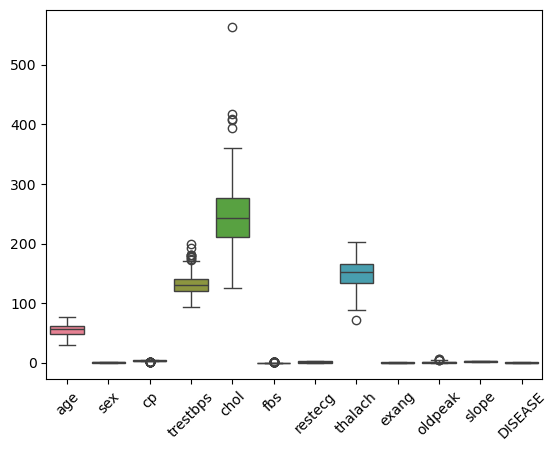

In [98]:
# Boxplots reveal the original feature scales before normalization
sns.boxplot(data)
plt.xticks(rotation= 45)
plt.show()

## 6. Feature Preparation

Create a working copy of the cleaned data, convert object columns into numeric values, and standardize selected continuous features. The target column is kept separate from the model input features.


In [99]:
# Work on a copy so the cleaned raw data remains available for comparison
data_updated = data.copy()

In [100]:
# Convert columns that were loaded as objects because of missing-value markers
for c in ["ca","thal"]:
    data_updated[c]= pd.to_numeric(data_updated[c], errors= "coerce")

In [101]:
# Standardize selected continuous features to have mean 0 and standard deviation 1
cols_scale= ["chol","thalach","trestbps","age"]

for col in cols_scale:
    num = pd.to_numeric(data_updated[col])
    data_updated[col] = (num - num.mean())/num.std(ddof = 1)

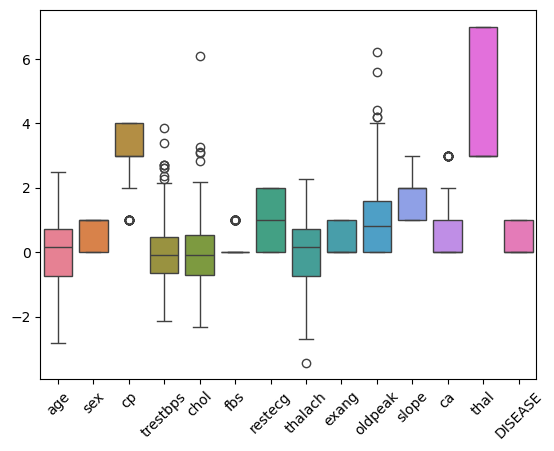

In [102]:
# Review the feature scales after standardization
sns.boxplot(data_updated)
plt.xticks(rotation= 45)
plt.show()

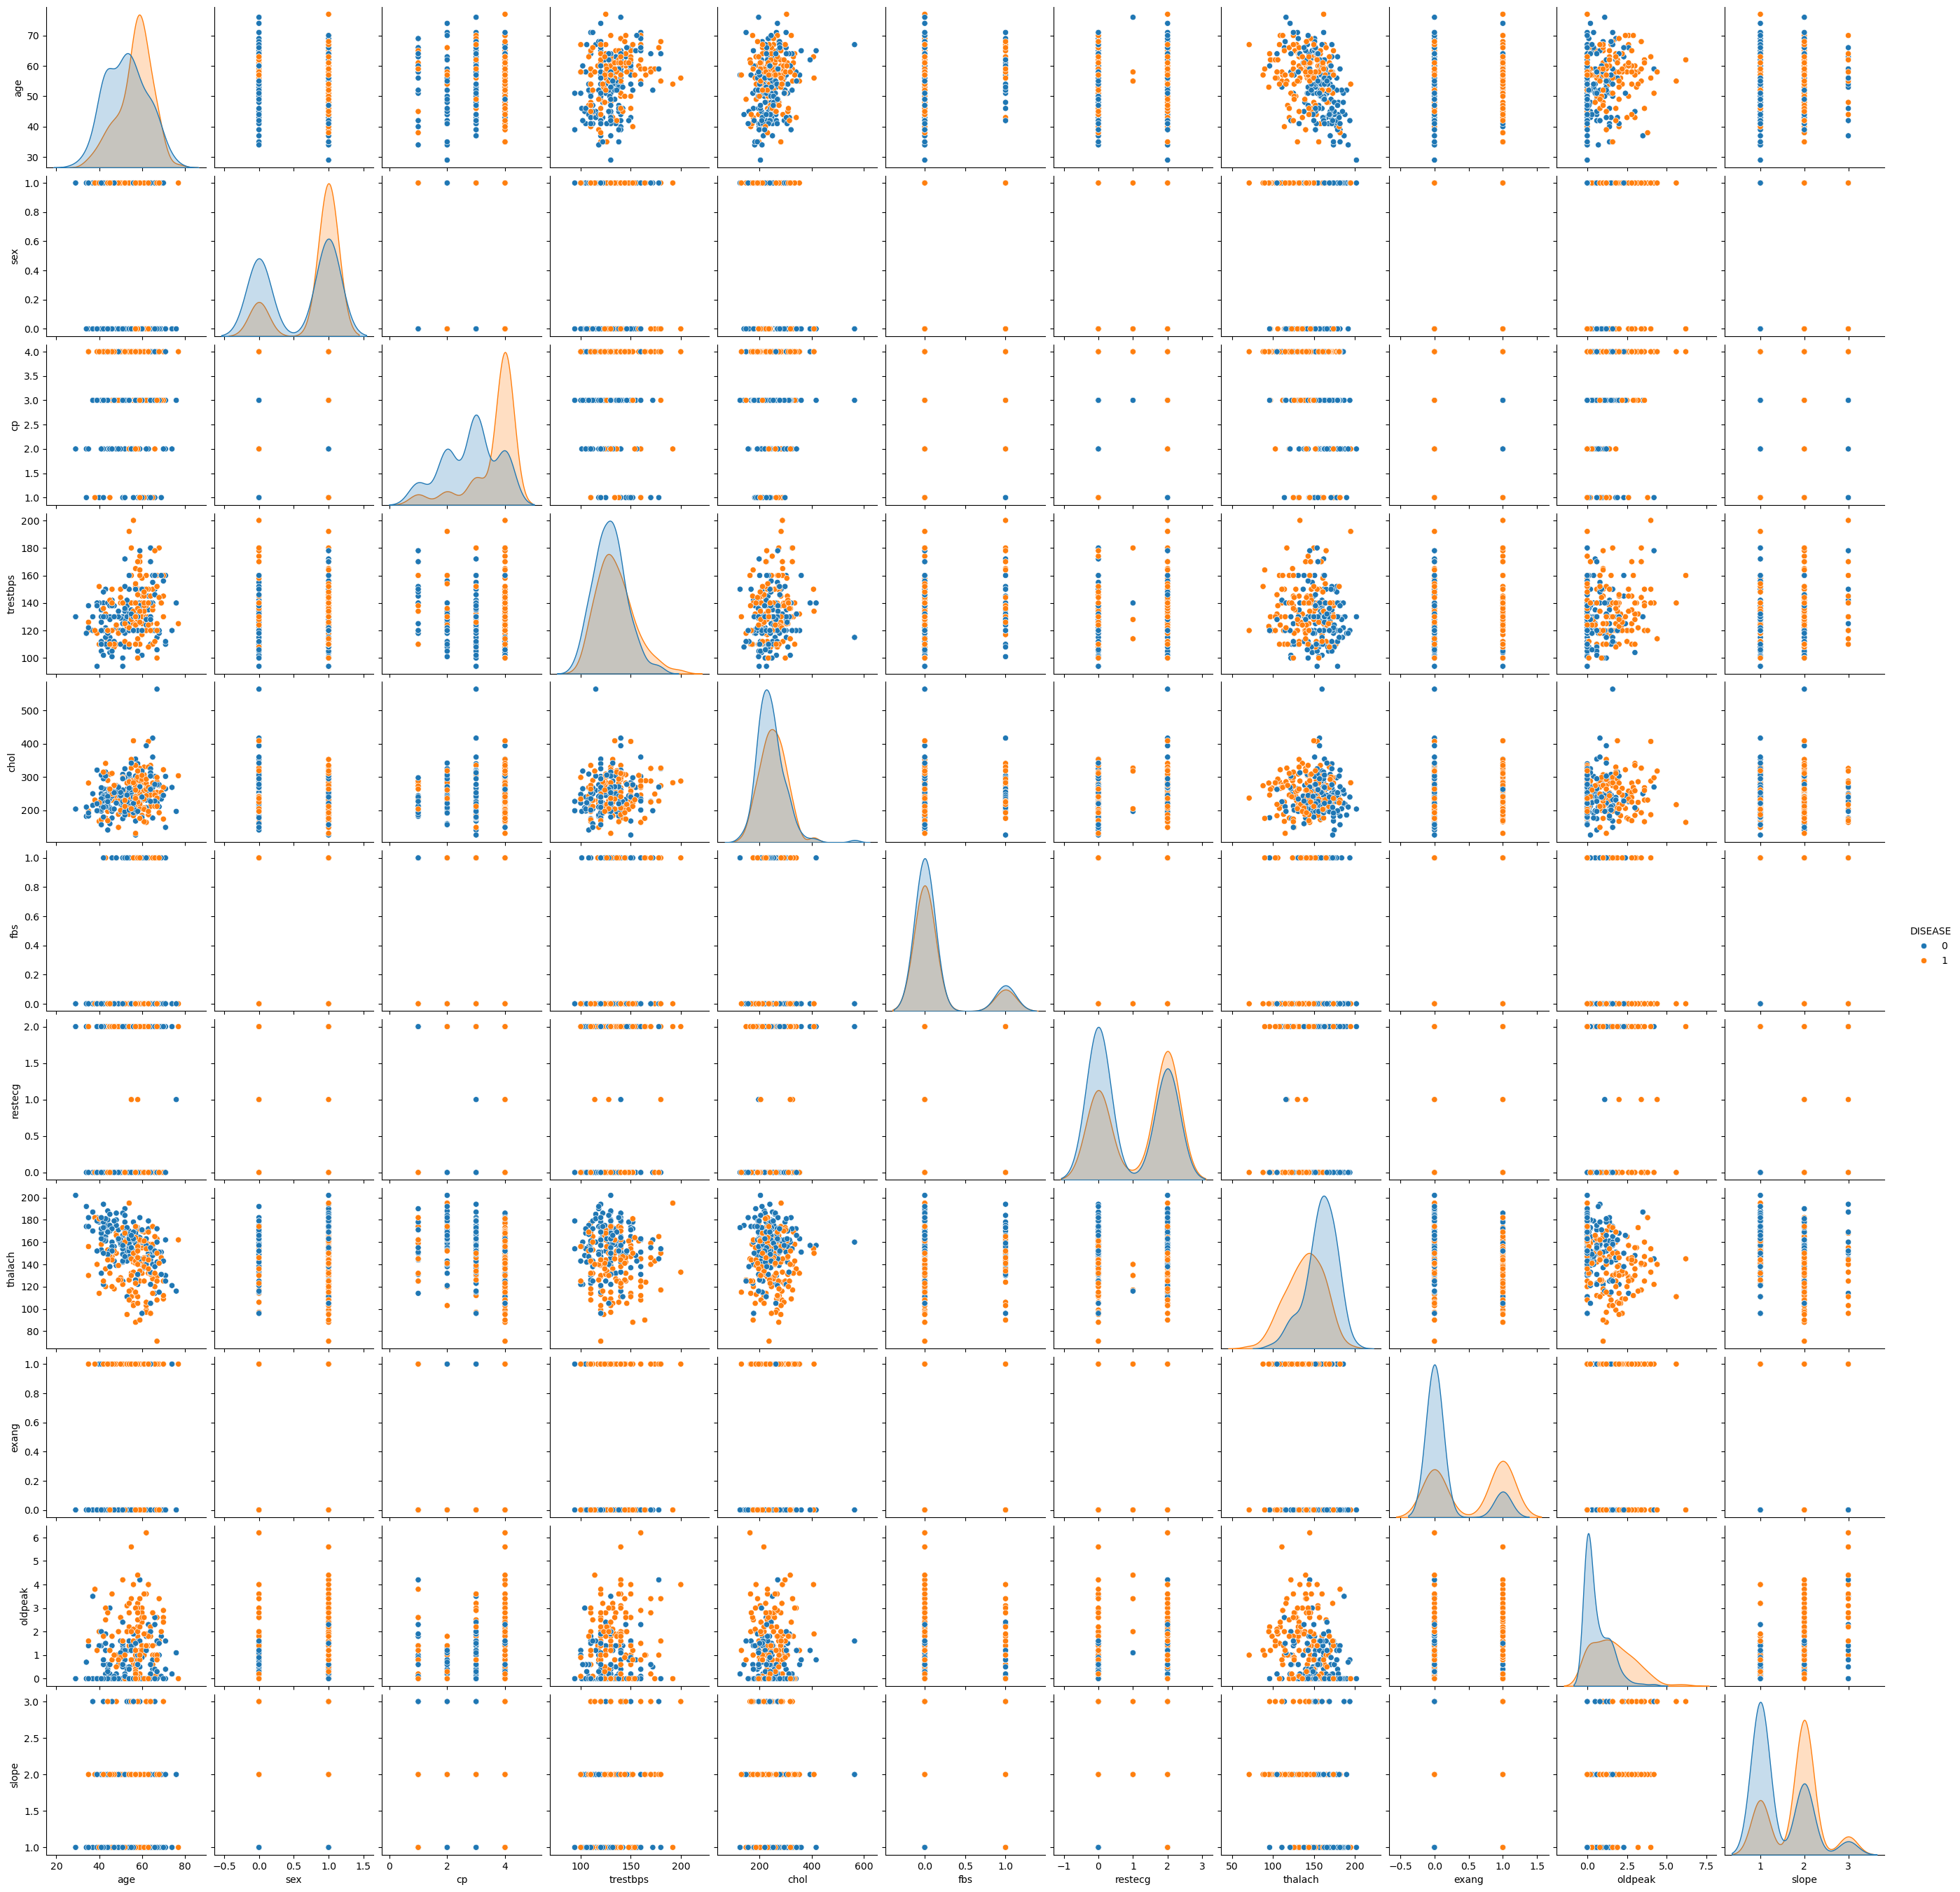

In [103]:
# Visualize pairwise relationships using the binary disease label
sns.pairplot(data, hue= "DISEASE")
plt.show()

In [104]:
# Separate the target from the input features
df_target = data_updated[["DISEASE"]]
df_feature = data_updated.drop(columns="DISEASE")

In [105]:
# Check the available values in the thal feature after conversion
df_feature.thal.unique()

array([6., 3., 7.])

In [106]:
# Confirm all feature columns are numeric before tensor conversion
df_feature.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
dtypes: float64(13)
memory usage: 32.5 KB


## 7. Convert Data to PyTorch Tensors

PyTorch models train on tensors. The features are stored as floating-point tensors, and the binary target is also stored as a floating-point tensor because `BCEWithLogitsLoss` expects float labels.


In [107]:
# Convert the pandas feature matrix and target column into PyTorch tensors
df_feature_tensor = torch.tensor(df_feature.values, dtype=torch.float32)
df_target_tensor = torch.tensor(df_target.values, dtype= torch.float32)

In [108]:
# Confirm that the target tensor has one label per row
df_target_tensor.shape

torch.Size([297, 1])

## 8. Train-Test Split and DataLoaders

Split the dataset into training and test sets. `TensorDataset` pairs features with labels, and `DataLoader` creates mini-batches for training.


In [109]:
# Keep 80% of the data for training and 20% for final testing
x_train, x_test, y_train, y_test = train_test_split(df_feature_tensor,df_target_tensor, train_size = 0.8, random_state= 42)

In [110]:
# Inspect the test labels after splitting
y_test

tensor([[0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.]])

In [111]:
# Wrap tensors in datasets and create mini-batch loaders
train_data = TensorDataset(x_train, y_train)
test_data = TensorDataset(x_test, y_test)

batchsize = 20
train_loader = DataLoader(train_data, batch_size = batchsize, shuffle = True, drop_last = True)
test_loader = DataLoader(test_data, batch_size = test_data.tensors[0].shape[0])

In [112]:
# Confirm the number of input features for the neural network
df_feature.shape

(297, 13)

## 9. Build the Feed-Forward Neural Network

The model receives 13 input features, passes them through fully connected hidden layers with ReLU activation, and returns one output logit for binary classification.


In [113]:
# Define a feed-forward neural network for binary classification
class theANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.input = nn.Linear(13,32)

        self.fc1 = nn.Linear(32, 64)
        self.fc2 = nn.Linear(64,10)
        
        self.output = nn.Linear(10,1)

    def forward(self,x):
        x= F.relu(self.input(x))
        x= F.relu(self.fc1(x))
        x=F.relu(self.fc2(x))
        return self.output(x)

## 10. Model Setup

Create the model, define the binary classification loss, choose the number of epochs, and initialize the optimizer. The model returns logits, so `BCEWithLogitsLoss` is the correct loss function.


In [114]:
# Instantiate the model and configure the training objective
ANNclass = theANN()
#lossfun = nn.CrossEntropyLoss()
lossfun = nn.BCEWithLogitsLoss()

numepoch = 250
losses = torch.zeros(numepoch)
learningRate = 0.0001
optimizer = torch.optim.Adam(ANNclass.parameters(), lr= learningRate)

## 11. Sanity Check the Model Output

Run one mini-batch through the network before training. This confirms that the model output shape matches the target shape expected by the loss function.


In [115]:
# Pull one training batch and check the raw model output
X,y = next(iter(train_loader))
ycheck = ANNclass(X)
ycheck

tensor([[0.2146],
        [0.2350],
        [0.2237],
        [0.2164],
        [0.2492],
        [0.2522],
        [0.2131],
        [0.2168],
        [0.2428],
        [0.2213],
        [0.2239],
        [0.2147],
        [0.2525],
        [0.2254],
        [0.2382],
        [0.1827],
        [0.2203],
        [0.2070],
        [0.2487],
        [0.2094]], grad_fn=<AddmmBackward0>)

In [116]:
# Check the target shape for one mini-batch
y.shape

torch.Size([20, 1])

In [117]:
# Check the model output shape for the same mini-batch
ycheck.shape

torch.Size([20, 1])

In [118]:
# Confirm the loss function can compare outputs and labels
lossfun(ycheck,y)

tensor(0.7095, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)

## 12. Train and Evaluate the Network

For each epoch, the model trains on mini-batches from the training set. After each epoch, it is evaluated on the full test set so the training and test curves can be compared.


In [119]:
# Store loss and accuracy values across epochs
trainLoss = torch.zeros(numepoch)
testLoss = torch.zeros(numepoch)
trainAcc = torch.zeros(numepoch)
testAcc = torch.zeros(numepoch)


for epochi in range(numepoch):
    batchLoss = []
    for X,y in train_loader:
        # Forward pass and loss calculation
        yhat = ANNclass(X)
        loss = lossfun(yhat, y)

        # Backpropagation and parameter update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batchLoss.append(loss.item())

        # Convert logits into binary predictions for accuracy tracking
        predictions = (torch.sigmoid(yhat)>.5).float()
        trainAcc[epochi] = 100*torch.mean((predictions==y).float())

    trainLoss[epochi] = np.mean(batchLoss)

    # Evaluate once per epoch on the full test set
    X_,y_ = next(iter(test_loader))
    yhat_ = ANNclass(X_)

    loss = lossfun(yhat_, y_)
    testLoss[epochi] = loss.item()

    predictions = (torch.sigmoid(yhat_)>0.5).float()
    testAcc[epochi] = 100*torch.mean((predictions==y_).float())

## 13. Training Curves

Plot the loss and accuracy curves to see how the network learns over time. A widening gap between training and test performance can indicate overfitting.


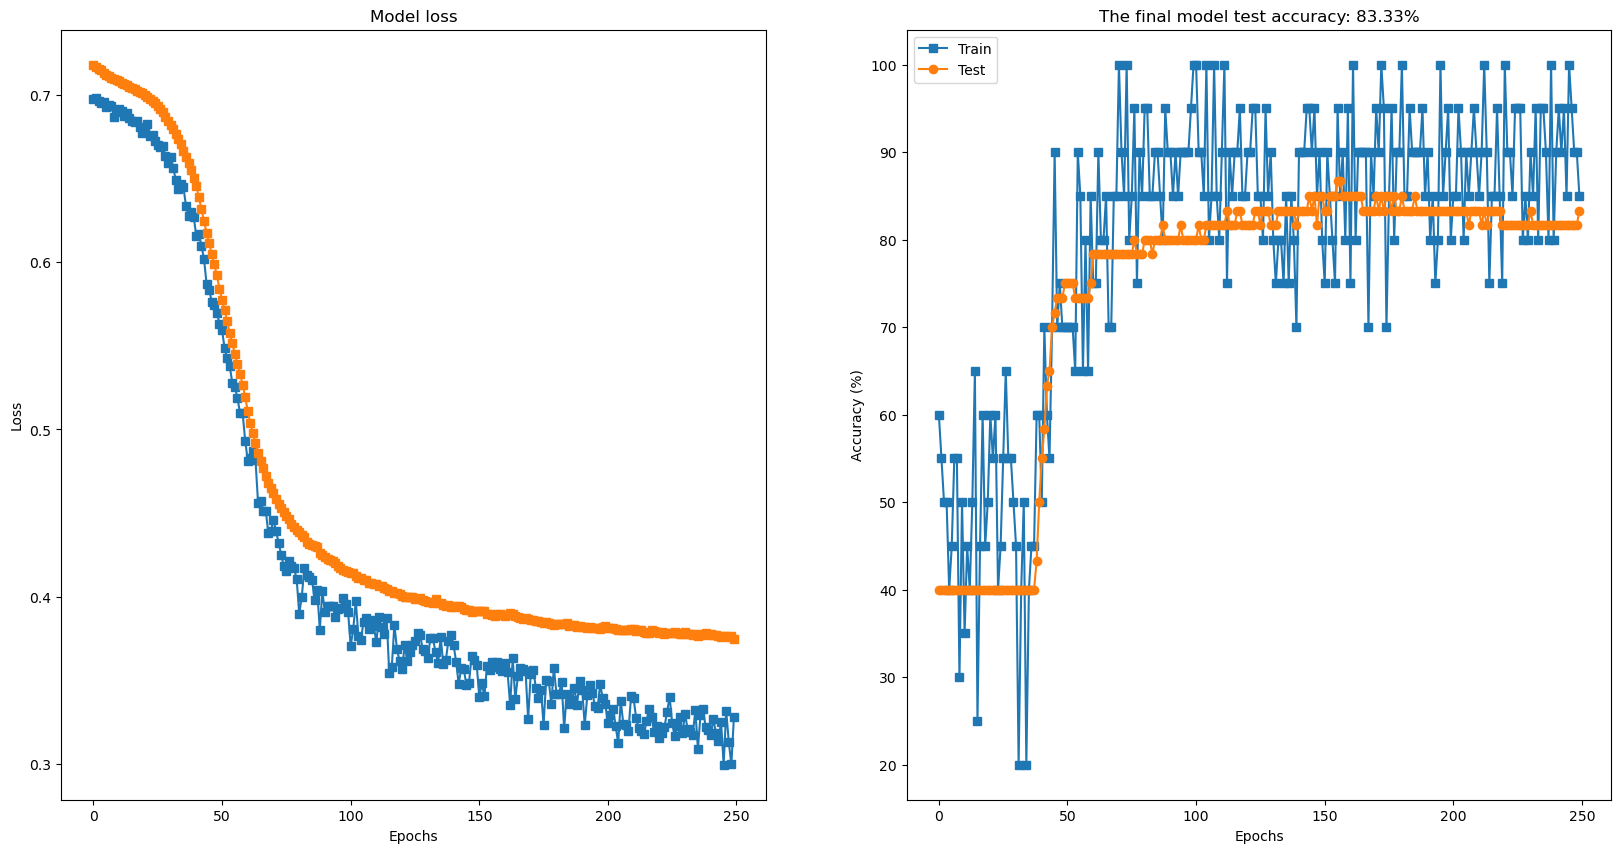

In [120]:
# Compare training and test performance over epochs
fig,ax = plt.subplots(1,2,figsize=(20,10))

ax[0].plot(trainLoss,'s-',label='Train')
ax[0].plot(testLoss,'s-',label='Test')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Model loss')

ax[1].plot(trainAcc,'s-',label='Train')
ax[1].plot(testAcc,'o-',label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title(f'The final model test accuracy: {testAcc[-1]:.2f}%')
ax[1].legend()

plt.show()

# Assignment

Use this notebook as a starting point for deeper practice.

1. Try several train-test split ratios and compare model performance.
2. Run the notebook several times without setting random seeds and observe how the results change.
3. Save example plots that show underfitting, good fitting, and overfitting.
4. Experiment with the learning rate, number of epochs, and model size to see how each choice affects the loss curves.

**Tip:** When diagnosing overfitting, compare both loss and accuracy curves instead of relying on final accuracy alone.
